# 0. # Notebook 03: Avaliação Final no Conjunto de Teste (Holdout) e Análise de Margens

Neste notebook, carregamos o dataset `fakerecogna_abstrativo.csv`, separamos o conjunto de teste de forma estritamente isolada e aplicamos o modelo **LinearSVC** otimizado para avaliar a sua robustez, gerar o relatório de diagnóstico e analisar a distribuição das margens de decisão (confiança do modelo).

📁 Diretório atual de execução: c:\Users\LAISA\OneDrive\Documentos\identificador-de-fake-news\notebooks\v2_pipeline_linearsvc
✅ Ficheiro encontrado com sucesso em: c:\Users\LAISA\OneDrive\Documentos\fakerecogna_abstrativo.csv
📊 Dimensão final processada: 52800 linhas.

🚀 Treinando o modelo LinearSVC...
✨ Treinamento concluído com sucesso!

--- RELATÓRIO DE DIAGNÓSTICO ---
Matriz de Confusão:
[[5017  263]
 [ 336 4944]]

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.94      0.95      0.94      5280
           1       0.95      0.94      0.94      5280

    accuracy                           0.94     10560
   macro avg       0.94      0.94      0.94     10560
weighted avg       0.94      0.94      0.94     10560



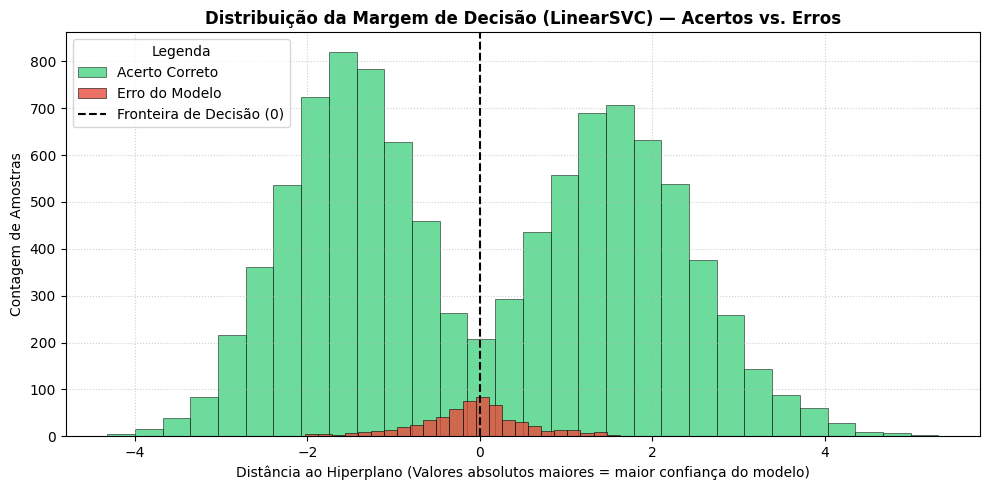

In [1]:
import os
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

# 1. Identificar o diretório atual do notebook
print("📁 Diretório atual de execução:", os.getcwd())

# 2. Caminho relativo subindo duas pastas (da subpasta para a raiz do projeto)
DATA_PATH = "../../fakerecogna_abstrativo.csv"

# Alternativa caso prefira caminho absoluto (remova a '#' da linha abaixo se necessário):
# DATA_PATH = r"C:/Users/LAISA/OneDrive/Documentos/identificador-de-fake-news/fakerecogna_abstrativo.csv"

if not os.path.exists(DATA_PATH):
  # Busca dinâmica subindo diretórios automaticamente
  current_dir = os.getcwd()
  for _ in range(3):
    current_dir = os.path.dirname(current_dir)
    test_path = os.path.join(current_dir, "fakerecogna_abstrativo.csv")
    if os.path.exists(test_path):
      DATA_PATH = test_path
      break

if not os.path.exists(DATA_PATH):
  raise FileNotFoundError(
      "❌ O ficheiro 'fakerecogna_abstrativo.csv' não foi encontrado. "
      "Certifique-se de que ele está na pasta raiz do projeto "
      "(C:/Users/LAISA/OneDrive/Documentos/identificador-de-fake-news/)."
  )

print(f"✅ Ficheiro encontrado com sucesso em: {os.path.abspath(DATA_PATH)}")

# 3. Carregar o dataset
df_raw = pd.read_csv(DATA_PATH)

# 4. Limpeza e separação estrita das colunas corretas
df_limpo = df_raw[["Noticia", "Label"]].dropna().copy()
df_limpo["Noticia"] = df_limpo["Noticia"].astype(str)
df_limpo["Label"] = df_limpo["Label"].astype(int)

X = df_limpo["Noticia"]  # 📝 Textos
y = df_limpo["Label"]  # 🏷️ Rótulos (0 ou 1)

print(f"📊 Dimensão final processada: {df_limpo.shape[0]} linhas.")

# 5. Divisão treino e teste (Holdout de 20%) com estratificação
X_train, X_ext, y_train, y_ext = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 6. Construir e treinar o Pipeline com TF-IDF + LinearSVC
pipeline = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(max_df=0.85, max_features=50000, ngram_range=(1, 2)),
    ),
    ("clf", LinearSVC(C=10.0, max_iter=2000, random_state=42)),
])

print("\n🚀 Treinando o modelo LinearSVC...")
pipeline.fit(X_train, y_train)
print("✨ Treinamento concluído com sucesso!\n")

# 7. Predições e Margens de Decisão
y_pred = pipeline.predict(X_ext)
confiancas = pipeline.decision_function(X_ext)

# 8. Relatório de Diagnóstico
print("--- RELATÓRIO DE DIAGNÓSTICO ---")
print("Matriz de Confusão:")
print(confusion_matrix(y_ext, y_pred))
print("\nRelatório de Classificação:")
print(classification_report(y_ext, y_pred, zero_division=0))

# 9. Gráfico de Margens de Decisão
df_auditoria = pd.DataFrame(
    {"Real": list(y_ext), "Predito": list(y_pred), "Margem_Hiperplano": confiancas}
)
df_auditoria["Acerto"] = df_auditoria["Real"] == df_auditoria["Predito"]

margens_acerto = df_auditoria[df_auditoria["Acerto"] == True][
    "Margem_Hiperplano"
]
margens_erro = df_auditoria[df_auditoria["Acerto"] == False][
    "Margem_Hiperplano"
]

plt.figure(figsize=(10, 5))
if len(margens_acerto) > 0:
  plt.hist(
      margens_acerto,
      bins=30,
      alpha=0.7,
      color="#2ecc71",
      label="Acerto Correto",
      edgecolor="black",
      linewidth=0.5,
  )
if len(margens_erro) > 0:
  plt.hist(
      margens_erro,
      bins=30,
      alpha=0.8,
      color="#e74c3c",
      label="Erro do Modelo",
      edgecolor="black",
      linewidth=0.5,
  )

plt.axvline(
    0,
    color="black",
    linestyle="--",
    linewidth=1.5,
    label="Fronteira de Decisão (0)",
)
plt.title(
    "Distribuição da Margem de Decisão (LinearSVC) — Acertos vs. Erros",
    fontsize=12,
    fontweight="bold",
)
plt.xlabel(
    "Distância ao Hiperplano (Valores absolutos maiores = maior confiança do"
    " modelo)",
    fontsize=10,
)
plt.ylabel("Contagem de Amostras", fontsize=10)
plt.legend(title="Legenda", loc="upper left")
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

### 💾 1. Salvamento do Modelo Treinado (Serialização)

Para evitar ter que reexecutar o treinamento completo sempre que formos rodar uma nova predição ou testar um dataset externo, salvamos o `pipeline` completo (que já inclui o `TfidfVectorizer` e o classificador `LinearSVC`) usando a biblioteca `joblib`.

In [2]:
import joblib

# Definir o nome e caminho do arquivo de saída do modelo
MODEL_PATH = "modelo_linearsvc_fakerecogna.joblib"

# Salvar o pipeline treinado
joblib.dump(pipeline, MODEL_PATH)
print(f"✅ Modelo treinado e salvo com sucesso em: {MODEL_PATH}")

# Exemplo de como recarregá-lo futuramente (caso precise em outro script):
# pipeline_carregado = joblib.load(MODEL_PATH)

✅ Modelo treinado e salvo com sucesso em: modelo_linearsvc_fakerecogna.joblib


### 🔍 2. Explicabilidade do Modelo: O que o LinearSVC aprendeu?

Como o `LinearSVC` utiliza coeficientes lineares associados a cada palavra do vocabulário TF-IDF, podemos extrair quais termos mais pesam para classificar uma notícia como **Verdadeira (0)** ou **Falsa (1)**.

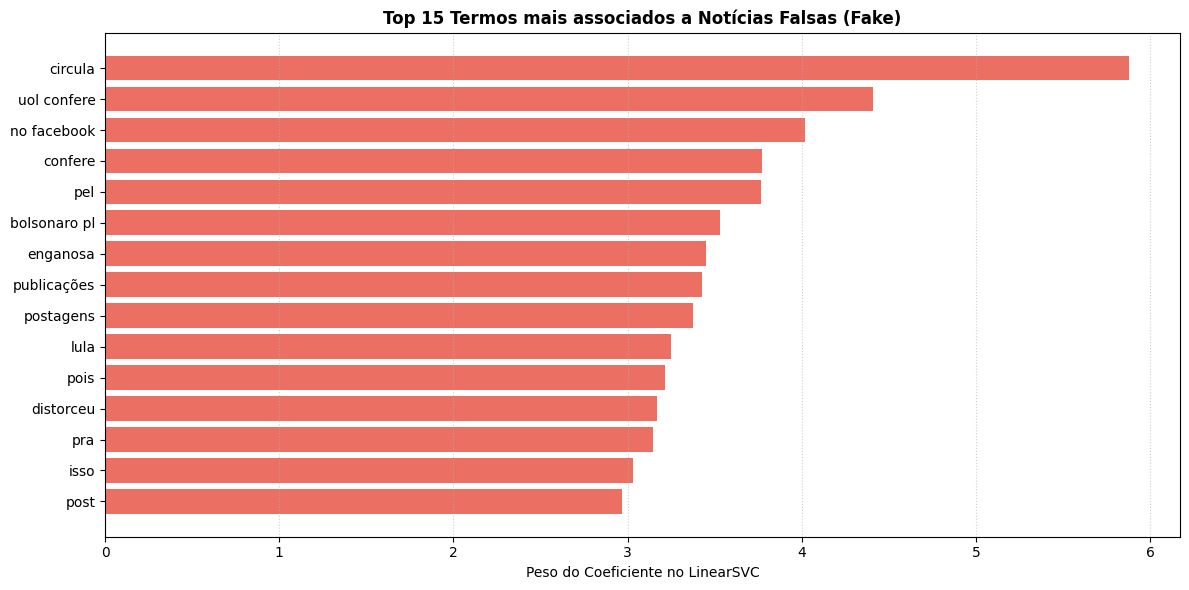

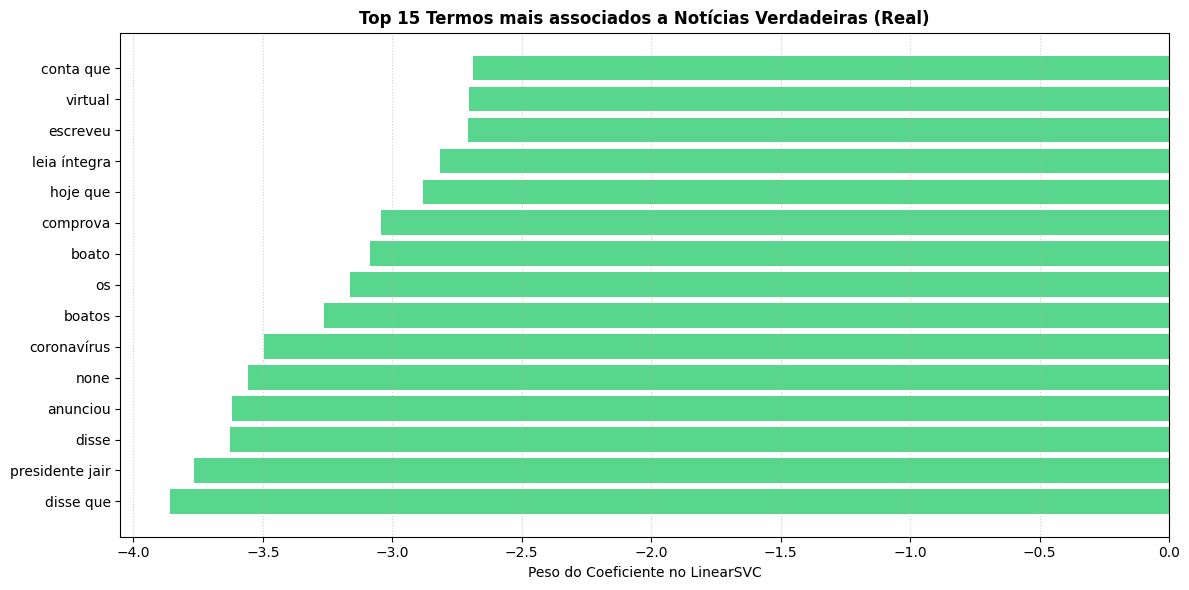

In [3]:
import numpy as np

# Extrair o vetorizador e o classificador de dentro do pipeline
vectorizer = pipeline.named_steps['tfidf']
classifier = pipeline.named_steps['clf']

# Obter nomes das features (palavras/n-grams) e os coeficientes do modelo
feature_names = vectorizer.get_feature_names_out()
coefficients = classifier.coef_[0]

# Encontrar os índices das palavras mais associadas a cada classe
top_fake_indices = np.argsort(coefficients)[-15:]  # Maiores coeficientes (Fake)
top_real_indices = np.argsort(coefficients)[:15]   # Menores coeficientes (Real)

# Criar gráfico de barras comparativo
plt.figure(figsize=(12, 6))

# Palavras que indicam Fake News (coeficientes positivos altos)
plt.barh(range(15), coefficients[top_fake_indices], align='center', color='#e74c3c', alpha=0.8)
plt.yticks(range(15), [feature_names[i] for i in top_fake_indices], fontsize=10)
plt.xlabel('Peso do Coeficiente no LinearSVC', fontsize=10)
plt.title('Top 15 Termos mais associados a Notícias Falsas (Fake)', fontsize=12, fontweight='bold')
plt.grid(axis='x', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
# Palavras que indicam Notícias Verdadeiras (coeficientes negativos altos)
plt.barh(range(15), coefficients[top_real_indices], align='center', color='#2ecc71', alpha=0.8)
plt.yticks(range(15), [feature_names[i] for i in top_real_indices], fontsize=10)
plt.xlabel('Peso do Coeficiente no LinearSVC', fontsize=10)
plt.title('Top 15 Termos mais associados a Notícias Verdadeiras (Real)', fontsize=12, fontweight='bold')
plt.grid(axis='x', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

### 🌐 3. Template para Validação Externa (Out-of-Distribution - OOD)

Se você possuir um segundo dataset coletado de outra fonte ou período temporal, utilize o bloco abaixo para testar a resiliência do modelo salvo sem alterar o vocabulário.

In [4]:
# --- DESCOMENTE ESTE BLOCO CASO TENHA UM SEGUNDO DATASET EXTERNO ---

# OOD_DATA_PATH = "seu_segundo_dataset.csv"
# if os.path.exists(OOD_DATA_PATH):
#     df_ood = pd.read_csv(OOD_DATA_PATH)
#
#     # Ajuste os nomes das colunas conforme o seu segundo dataset
#     X_ood = df_ood['Noticia'].astype(str)
#     y_ood = df_ood['Label'].astype(int)
#
#     # Carrega o modelo salvo e prediz diretamente (sem fit!)
#     modelo_carregado = joblib.load("modelo_linearsvc_fakerecogna.joblib")
#     y_pred_ood = modelo_carregado.predict(X_ood)
#
#     print("--- RELATÓRIO DE VALIDAÇÃO EXTERNA (OOD) ---")
#     print(confusion_matrix(y_ood, y_pred_ood))
#     print(classification_report(y_ood, y_pred_ood, zero_division=0))
# else:
#     print("ℹ️ Nenhum dataset OOD configurado no momento. Etapa opcional pronta para uso futuro.")

# 4. Bloco de Diagnóstico Avançado e Auditoria de Erros

In [5]:
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report

print("="*60)
print("🔬 INICIANDO RELATÓRIO DE DIAGNÓSTICO E AUDITORIA AVANÇADA")
print("="*60)

# Criar DataFrame consolidado de auditoria
df_auditoria = pd.DataFrame({
    'Texto': X_ext.values if hasattr(X_ext, 'values') else X_ext,
    'Real': y_ext.values if hasattr(y_ext, 'values') else y_ext,
    'Predito': y_pred,
    'Margem_Hiperplano': confiancas
})
df_auditoria['Acerto'] = df_auditoria['Real'] == df_auditoria['Predito']

# -------------------------------------------------------------
# 1. ANÁLISE DE SOBREPOSIÇÃO DE VOCABULÁRIO (Taxa OOV)
# -------------------------------------------------------------
vectorizer = pipeline.named_steps['tfidf']
vocabulario_treino = set(vectorizer.get_feature_names_out())

tokens_externos = set()
for texto in df_auditoria['Texto']:
    tokens_externos.update(str(texto).lower().split())

tokens_oov = tokens_externos - vocabulario_treino
taxa_oov = (len(tokens_oov) / len(tokens_externos)) * 100 if tokens_externos else 0

print(f"\n[1] ANÁLISE DE VOCABULÁRIO (OOV)")
print(f"   - Total de tokens únicos no treino: {len(vocabulario_treino):,}")
print(f"   - Total de tokens únicos no teste: {len(tokens_externos):,}")
print(f"   - Taxa OOV: {taxa_oov:.2f}% dos tokens são totalmente novos.")

# -------------------------------------------------------------
# 2. INSPEÇÃO QUALITATIVA DE ERROS (Error Deep Dive)
# -------------------------------------------------------------
falsos_positivos = df_auditoria[(df_auditoria['Real'] == 0) & (df_auditoria['Predito'] == 1)]
falsos_negativos = df_auditoria[(df_auditoria['Real'] == 1) & (df_auditoria['Predito'] == 0)]

print(f"\n[2] INSPEÇÃO QUALITATIVA DE ERROS")
print(f"   - Falsos Positivos (Eram reais, modelo classificou como Fake): {len(falsos_positivos)}")
print(f"   - Falsos Negativos (Eram fake, modelo classificou como Real): {len(falsos_negativos)}")

if len(falsos_positivos) > 0:
    print(f"\n   ⚠️ Exemplo de Falso Positivo:")
    print(f"      \"{str(falsos_positivos.iloc[0]['Texto'])[:250]}...\"")

if len(falsos_negativos) > 0:
    print(f"\n   ⚠️ Exemplo de Falso Negativo:")
    print(f"      \"{str(falsos_negativos.iloc[0]['Texto'])[:250]}...\"")

# -------------------------------------------------------------
# 3. ANÁLISE DA DISTRIBUIÇÃO DA MARGEM DE CONFIANÇA
# -------------------------------------------------------------
acertos_mask = df_auditoria['Acerto'] == True
erros_mask = df_auditoria['Acerto'] == False

margem_acerto_media = np.abs(df_auditoria[acertos_mask]['Margem_Hiperplano']).mean() if acertos_mask.sum() > 0 else 0
margem_erro_media = np.abs(df_auditoria[erros_mask]['Margem_Hiperplano']).mean() if erros_mask.sum() > 0 else 0

print(f"\n[3] DISTRIBUIÇÃO DA MARGEM DE CONFIANÇA (.decision_function)")
print(f"   - Margem média dos acertos (absoluta): {margem_acerto_media:.4f}")
print(f"   - Margem média dos erros (absoluta): {margem_erro_media:.4f}")

# -------------------------------------------------------------
# 4. MÉTRICAS POR SUBGRUPOS (Slicing Analysis - Blindado)
# -------------------------------------------------------------
print(f"\n[4] MÉTRICAS POR SUBGRUPOS (Slicing Analysis)")
col_sub = None
for candidate in ['Categoria', 'subgrupo', 'categoria', 'domain', 'tema']:
    if candidate in df_raw.columns:
        col_sub = candidate
        break

if col_sub:
    df_slicing = df_raw.loc[X_ext.index].copy()
    df_slicing['Predito'] = y_pred
    
    for subgrupo in df_slicing[col_sub].dropna().unique():
        sub_df = df_slicing[df_slicing[col_sub] == subgrupo]
        if len(sub_df) > 0:
            print(f"\n   --- Subgrupo: {subgrupo} (n={len(sub_df)}) ---")
            try:
                print(classification_report(sub_df['Label'], sub_df['Predito'], zero_division=0))
            except Exception as e:
                print(f"   ⚠️ Impossível calcular relatório para este subgrupo: {e}")
else:
    print("   ℹ️ Nenhuma coluna de subgrupo/categoria identificada no dataset atual (comportamento normal para datasets binários simples).")

print("\n" + "="*60)

🔬 INICIANDO RELATÓRIO DE DIAGNÓSTICO E AUDITORIA AVANÇADA

[1] ANÁLISE DE VOCABULÁRIO (OOV)
   - Total de tokens únicos no treino: 50,000
   - Total de tokens únicos no teste: 77,856
   - Taxa OOV: 80.59% dos tokens são totalmente novos.

[2] INSPEÇÃO QUALITATIVA DE ERROS
   - Falsos Positivos (Eram reais, modelo classificou como Fake): 263
   - Falsos Negativos (Eram fake, modelo classificou como Real): 336

   ⚠️ Exemplo de Falso Positivo:
      "o ex-governador do rio de janeiro sérgio cabral foi denunciado por corrupção passiva e ativa. de acordo com a denúncia, maciste teria efetuado oito pagamentos à organização criminosa. a construtora macadame possui contratos com o departamento de estr..."

   ⚠️ Exemplo de Falso Negativo:
      "não existe dia do professor no japão. “uma vez perguntei ao meu colega japonês, o professor yamamoto: – quando o japão comemora o dia dos professores, como é que o comemora? surpreendido com a minha pergunta, ele respondeu: – não temos feriado de pro.